In [1]:
import os
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, PeftModel

torch.cuda.empty_cache()

# model_name = "meta-llama/Llama-3.2-1B"
model_name = "Qwen/Qwen3-0.6B"
model_save_dir = "model/downloaded"
adapter_save_dir = "model/downloaded/qwen3_0.6b_med_3eps_test"
os.makedirs(model_save_dir, exist_ok=True)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype="auto",
    device_map="cuda",
    cache_dir=model_save_dir
)
peft_model = PeftModel.from_pretrained(
    model,
    adapter_save_dir)

In [2]:
import torch
@torch.no_grad()
def partial_brain_surgeon(
    X_hat,
    M,
    B,
    A,
    W,
    reg=1e-8,
    keep_weight=1.0,
    max_pruned_per_row=None,
    eps=1e-12,
    inplace=False,
    xhat_is_squared=True,
):
    """
    Adapter recovery under a fixed mask M (single-layer, closed-form), updating B only (A fixed).

    This version matches the common transformer Linear shapes you provided:
        X_hat:   [1, 1, n]  (here n=1024)  -> interpreted as per-input-feature energy
        W:       [m, n]     (here m=2048, n=1024)
        B:       [m, r]     (here r=8)
        A:       [r, n]

    IMPORTANT: With X_hat shaped like (.., n), we treat it as *column weights*:
        g_j ≈ (X^T X)_{jj} = ||X_{:,j}||_2^2,  j=1..n

    Row-wise objective (for each output row i):
        min_{Δb_i}
            || (U_{i,S_i} + Δb_i A_{:,S_i}) diag(sqrt(g_{S_i})) ||_2^2
          + keep_weight * || (Δb_i A_{:,K_i}) diag(sqrt(g_{K_i})) ||_2^2
          + reg * ||Δb_i||_2^2

    where U = W + BA (current effective weight),
          S_i are pruned columns in row i, K_i are kept columns in row i.

    Closed form uses weighted Grams:
        A D A^T and A_{S} D_S A_{S}^T, with D=diag(g).

    Args:
        X_hat: Tensor with last dim = n (preferred), e.g. [1,1,n] or [n].
               If last dim == m, we fall back to row-weighting (older behavior).
        M:     Binary mask [m,n], 0=pruned, 1=kept.
        B,A,W: As above.
        reg:   Ridge (Tikhonov) coefficient.
        keep_weight: Strength of "do-no-harm on kept coordinates" penalty.
        max_pruned_per_row: Optional cap on |S_i| via largest |U_{i,S_i}|.
        eps:   Numerical floor for g.
        inplace: Update B in-place if True.
        xhat_is_squared: If True, X_hat already stores ||X_{:,j}||^2.
                         If False, we will square it to get g.

    Returns:
        Updated B with same shape/device/dtype as input B.
    """
    # dtype/device harmonization
    if B.dtype != A.dtype:
        B = B.to(A.dtype)
    device = A.device
    dtype = A.dtype

    # shapes
    m, r = B.shape
    rA, n = A.shape
    assert rA == r, f"A has shape {A.shape}, but B has r={r}."
    assert W.shape == (m, n), f"W shape {W.shape} must be (m,n)=({m},{n})."
    assert M.shape == (m, n), f"M shape {M.shape} must be (m,n)=({m},{n})."

    # move mask once to GPU
    M_dev = M.to(device=device)

    # clone or inplace
    B_new = B if inplace else B.clone()

    # current effective weight
    U = W + B_new @ A  # (m, n)

    # parse X_hat into a 1D vector
    g_raw = X_hat
    if not torch.is_tensor(g_raw):
        g_raw = torch.tensor(g_raw)
    g_raw = g_raw.to(device=device, dtype=dtype).reshape(-1)

    # Two supported interpretations:
    g = g_raw
    if not xhat_is_squared:
        g = g * g
    g = torch.clamp(g, min=eps)  # (n,)

    # Precompute A D A^T with D=diag(g):  ADAT = A diag(g) A^T
    # Efficiently: (A * g) @ A^T where g broadcasts over columns
    ADAT = (A * g.unsqueeze(0)) @ A.t()  # (r, r)

    I_r = torch.eye(r, device=device, dtype=dtype)
    reg_t = torch.tensor(reg, device=device, dtype=dtype)

    for i in range(m):
        # pruned columns in this row
        S_i = (M_dev[i] == 0).nonzero(as_tuple=True)[0]
        if S_i.numel() == 0:
            continue

        # optionally cap |S_i|
        if max_pruned_per_row is not None and S_i.numel() > max_pruned_per_row:
            x_pruned = U[i, S_i].abs()
            topk = torch.topk(x_pruned, k=max_pruned_per_row, largest=True).indices
            S_i = S_i[topk]

        # gather sub-vectors/matrices
        g_S = g[S_i]                 # (k,)
        A_S = A[:, S_i]              # (r, k)
        x_S = U[i, S_i]              # (k,)

        # Weighted Gram on pruned set: A_S diag(g_S) A_S^T
        # via (A_S * g_S) @ A_S^T
        ApDpApT = (A_S * g_S.unsqueeze(0)) @ A_S.t()  # (r, r)

        # Using identity: A_K D_K A_K^T = ADAT - ApDpApT
        # Gram = ApDpApT + keep_weight*(ADAT - ApDpApT) + reg I
        #      = keep_weight*ADAT + (1-keep_weight)*ApDpApT + reg I
        Gram = keep_weight * ADAT + (1.0 - keep_weight) * ApDpApT + reg_t * I_r  # (r, r)

        # rhs = x_S diag(g_S) A_S^T  == (x_S * g_S) @ A_S^T
        rhs = (x_S * g_S) @ A_S.t()  # (r,)

        # Solve Gram * z = rhs^T  => delta_b = -z^T (row vector)
        z = torch.linalg.solve(Gram, rhs.unsqueeze(1)).squeeze(1)  # (r,)
        B_new[i] = B_new[i] - z

    return B_new


In [ ]:
from pruning.utils import (get_layers, 
                    find_layers, 
                    layer_forward, 
                    return_given_alpha, 
                    prepare_calibration_input, 
                    merge_lora_into_base, 
                    reset_lora,
                    get_comp_norm)
from pruning.WrappedGPT import WrappedGPT
from peft.tuners.lora import Linear

@torch.no_grad()
def foresight_prune(model,
                dataloader, 
                prune_ratio,
                mask_lr,
                nsamples=128,
                device=None,
                merge_lora=True,
                PBS=True):
    use_cache = model.config.use_cache
    model.config.use_cache = False

    num_q_heads = model.config.num_attention_heads
    head_dim = model.config.head_dim
    num_kv_groups = model.config.num_key_value_heads

    model.eval()
    if device is None:
        device = next(model.parameters()).device

    print("preparing calibration input")
    with torch.no_grad():
        inps, outs, attention_mask, position_ids = prepare_calibration_input(model, dataloader)
    print("calibration input prepared")

    layers = get_layers(model)
    
    for i in range(len(layers)):
        layer = layers[i]
        subset = find_layers(layer, layers=(Linear,))

        # Handle model parallel device map (optional)
        if hasattr(model, "hf_device_map") and f"model.layers.{i}" in model.hf_device_map:
            dev = model.hf_device_map[f"model.layers.{i}"]
            inps = inps.to(dev)
            outs = outs.to(dev)
            attention_mask = attention_mask.to(dev) if attention_mask is not None else None
            position_ids = position_ids.to(dev) if position_ids is not None else None
        else:
            dev = inps.device

        # Wrap linears to collect activation stats
        wrapped_layers = {name: WrappedGPT(mod.base_layer, layer_id=i, layer_name=name) for name, mod in subset.items()}

        def add_batch(name):
            def _hook(mod, inp, out):
                # inp is a tuple; inp[0] is the tensor input to this Linear
                wrapped_layers[name].add_batch(inp[0].detach(), out.detach())
            return _hook

        handles = []
        for name, mod in subset.items():
            handles.append(mod.register_forward_hook(add_batch(name)))

        # Run layer forward nsamples times to populate wrapped_layers[name].scaler_row
        # IMPORTANT: Use Qwen3-correct layer forward (provides position_embeddings)
        for j in range(nsamples):
            hs = inps[j].unsqueeze(0)  # [1, seqlen, hidden]
            outs[j] = layer_forward(
                model=model,
                layer=layer,
                hidden_states=hs,
                attention_mask=attention_mask,
                position_ids=position_ids,
            ).squeeze(0)

        for h in handles:
            h.remove()

        #please edit the following part to compute correct importance score and add it to score, set mask based on the importance score
        for name in subset:
            # Access the relevant tensors for each module.
            print(f"Pruning layer {i}, param {name}")
            # print(torch.cuda.memory_allocated() / 1e9, torch.cuda.memory_reserved() / 1e9)
            weight       = subset[name].base_layer.weight
            lora_A       = subset[name].lora_A.default.weight
            lora_B       = subset[name].lora_B.default.weight
            if not hasattr(subset[name], "score") or subset[name].score is None:
                subset[name].score = torch.zeros_like(weight, device=torch.device("cpu"))
            score_tensor = subset[name].score
            # X_hat is computed from the activation statistics (assumed to be feature norm)
            X_hat = torch.sqrt(wrapped_layers[name].scaler_row.reshape((1, -1))).to(mod.weight.device)
            # Save the original devices for score and mask
            orig_score_device = score_tensor.device

            # Move score and mask to the current computation device (assume weight's device)
            device = weight.device
            if score_tensor.device != device:
                score_tensor = score_tensor.to(device)

            if name == "self_attn.q_proj":
                effective_weight = weight + torch.matmul(lora_B, lora_A)
                effective_weight_Q = effective_weight.view(num_q_heads, head_dim, -1)
                abs_Q = torch.abs(effective_weight_Q)
                comp_layer = subset["self_attn.k_proj"]
                comp_weight = comp_layer.base_layer.weight + torch.matmul(
                    comp_layer.lora_B.default.weight,
                    comp_layer.lora_A.default.weight,
                )
                effective_weight_K = comp_weight.view(num_kv_groups, head_dim, -1)
                kv_group_norms = torch.norm(effective_weight_K, p=2, dim=1)
                group_size = num_q_heads // num_kv_groups
                kv_group_idx = torch.arange(num_q_heads, device=abs_Q.device) // group_size  # [num_q_heads]
                kv_norms_expanded = kv_group_norms[kv_group_idx]
                X_hat = X_hat.view(1, 1, -1).to(abs_Q.device)
                importance = torch.mul(abs_Q, kv_norms_expanded.unsqueeze(1))
                importance = torch.mul(importance, X_hat)
                importance = importance.view(-1, importance.shape[-1])

            if name == "self_attn.k_proj":
                effective_weight = weight + torch.matmul(lora_B, lora_A)
                k_weight_grouped = effective_weight.view(num_kv_groups, head_dim, -1)
                k_weight_abs = torch.abs(k_weight_grouped)
                comp_layer = subset["self_attn.q_proj"]
                q_weight = comp_layer.base_layer.weight + torch.matmul(
                    comp_layer.lora_B.default.weight,
                    comp_layer.lora_A.default.weight,
                )
                group_size = num_q_heads // num_kv_groups
                q_weight_grouped = q_weight.view(num_kv_groups, group_size, head_dim, -1)
                q_head_norm = torch.norm(q_weight_grouped, p=2, dim=2)
                q_group_norm = torch.sqrt(torch.mean(torch.mul(q_head_norm, q_head_norm), dim=1, keepdim=True))
                X_hat = X_hat.view(1, 1, -1).to(k_weight_abs.device)
                importance_grouped = torch.mul(k_weight_abs, q_group_norm)
                importance_grouped = torch.mul(importance_grouped, X_hat)
                importance = importance_grouped.view(-1, importance_grouped.shape[-1])

            elif name == "self_attn.v_proj":
                # Compute effective v_proj weight: shape [512, 2048] → 8 heads × 64 rows
                effective_weight = weight + torch.matmul(lora_B, lora_A)
                out_features, in_features = effective_weight.shape
                g = num_q_heads // num_kv_groups
                Wv_h = effective_weight.view(num_kv_groups, head_dim, in_features)  # [h_kv, d_h, in_features]
                comp_layer = subset["self_attn.o_proj"]
                comp_weight = comp_layer.base_layer.weight + torch.matmul(
                                    comp_layer.lora_B.default.weight,
                                    comp_layer.lora_A.default.weight)
                
                Wo_blocks = comp_weight.view(comp_weight.shape[0], num_q_heads, head_dim)
                Wo_grouped = Wo_blocks.view(comp_weight.shape[0], num_kv_groups, g, head_dim)
                tmp = torch.norm(Wo_grouped, p=2, dim=0)          # norm over out_dim -> [h_kv, g, d_h]
                comp_kv = torch.sqrt(tmp.pow(2).mean(dim=1))       # RMS over g -> [h_kv, d_h]
                importance_grouped = torch.abs(Wv_h) * comp_kv.unsqueeze(-1) * X_hat  # shape: (8, 64, 2048)
                importance = importance_grouped.view(out_features, in_features)

            elif name == "self_attn.o_proj":
                # Compute o_proj effective weight: (2048, 2048)
                effective_weight = weight + torch.matmul(lora_B, lora_A)

                norm_gate = get_comp_norm(comp = subset["mlp.gate_proj"], dim=0)
                norm_up   = get_comp_norm(comp = subset["mlp.up_proj"], dim=0)
                norm = (norm_gate + norm_up) / 2
                norm = norm.reshape(-1, 1)
                # Compute importance as per:
                # importance_{ij} = |(W1+B1A1)_{ij}| * ||X_{:,i}||_2 * (norm_gate + norm_up)_j
                importance = torch.abs(effective_weight) * X_hat * norm
            elif name == "mlp.gate_proj":
                effective_weight = weight + torch.matmul(lora_B, lora_A)
                comp_norm = get_comp_norm(comp = subset["mlp.down_proj"], dim=1)
                importance = torch.abs(effective_weight) * comp_norm * X_hat  # shape: (8192, 2048)
            elif name == "mlp.up_proj":
                # effective_weight: shape [8192, 2048]
                effective_weight = weight + torch.matmul(lora_B, lora_A)
                comp_norm = get_comp_norm(comp = subset["mlp.down_proj"], dim=1)
                importance = torch.abs(effective_weight) * comp_norm * X_hat
            elif name == "mlp.down_proj":
                effective_weight = weight + torch.matmul(lora_B, lora_A)
                importance = torch.abs(effective_weight) * X_hat
            else:
                print("This weight is not being recognized " + name)
                comp_weight = None

            if torch.count_nonzero(score_tensor) > 0:
                # Moving average: new_score = mask_lr * current + (1 - mask_lr) * previous
                print("we use moving average")
                importance = mask_lr * importance + (1 - mask_lr) * score_tensor

            # Update the stored score.
            score_tensor.copy_(importance)
            if score_tensor.device != orig_score_device:
                score_tensor = score_tensor.to(orig_score_device)
            # merge the lora adpater, apply the mask, and reinitialized the lora adapter
            
            # Rowwise Selection
            W_mask = torch.zeros_like(importance, dtype=torch.bool)
            num_to_prune = int(importance.shape[1] * prune_ratio)
            sort_res = torch.sort(importance, dim=-1, stable=True)
            indices = sort_res[1][:, :num_to_prune]
            rows = torch.arange(importance.shape[0]).unsqueeze(-1).to(importance.device)
            W_mask[rows, indices] = True

            if PBS:
                # Perform partial brain surgeon recovery
                print("Performing PBS recovery")
                lora_B_new = partial_brain_surgeon(
                    X_hat=X_hat,
                    M=~W_mask,
                    B=lora_B,
                    A=lora_A,
                    W=weight,
                    reg=1e-8,
                    keep_weight=1.0,
                    max_pruned_per_row=None,
                    eps=1e-12,
                    inplace=True,
                )

            if merge_lora:
                merge_lora_into_base(subset[name], adapter="default")
                reset_lora(subset[name], adapter="default")
            
            weight.masked_fill_(W_mask, 0.0)


        for j in range(min(128, inps.shape[0])):
            with torch.no_grad():
                pos_emb = model.base_model.model.model.rotary_emb(x = inps[j].unsqueeze(0),position_ids = position_ids)
                outs[j] = layer(
                    inps[j].unsqueeze(0),
                    attention_mask=attention_mask,
                    position_ids=position_ids,
                    position_embeddings=pos_emb
                )[0]
        inps, outs = outs, inps

    # Restore original cache setting
    model.config.use_cache = use_cache
    torch.cuda.empty_cache()

In [4]:
# from pruning.prune import foresight_prune, prune_wanda
from data.datasets import get_loaders

dataloader, _ = get_loaders(
    name="harrison",
    tokenizer=tokenizer,
    seqlen=2048,
    nsamples=128)

foresight_prune(model=peft_model,
                dataloader=dataloader,
                prune_ratio=0.4,
                mask_lr=0.5,
                nsamples=128)

# model = peft_model.merge_and_unload()
# prune_wanda(sparsity_ratio=0.4,
#             nsamples=128,
#             seed=42,
#             seqlen=2048,
#             model=model,
#             tokenizer=tokenizer,
#             dataset_name="harrison")

Token indices sequence length is longer than the specified maximum sequence length for this model (4914897 > 131072). Running this sequence through the model will result in indexing errors


preparing calibration input
calibration input prepared
Pruning layer 0, param self_attn.q_proj
This weight is not being recognized self_attn.q_proj
Pruning layer 0, param self_attn.k_proj
Pruning layer 0, param self_attn.v_proj
Pruning layer 0, param self_attn.o_proj
Pruning layer 0, param mlp.gate_proj
Pruning layer 0, param mlp.up_proj
Pruning layer 0, param mlp.down_proj
Pruning layer 1, param self_attn.q_proj
This weight is not being recognized self_attn.q_proj
Pruning layer 1, param self_attn.k_proj
Pruning layer 1, param self_attn.v_proj
Pruning layer 1, param self_attn.o_proj
Pruning layer 1, param mlp.gate_proj
Pruning layer 1, param mlp.up_proj
Pruning layer 1, param mlp.down_proj
Pruning layer 2, param self_attn.q_proj
This weight is not being recognized self_attn.q_proj
Pruning layer 2, param self_attn.k_proj
Pruning layer 2, param self_attn.v_proj
Pruning layer 2, param self_attn.o_proj
Pruning layer 2, param mlp.gate_proj
Pruning layer 2, param mlp.up_proj
Pruning layer 2,

torch.Size([3072, 1024])


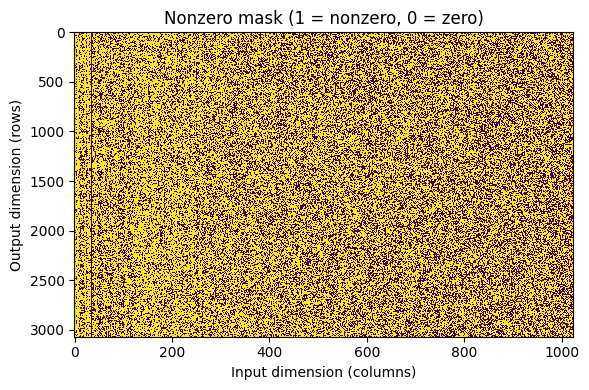

In [7]:
import matplotlib.pyplot as plt

W = model.model.layers[0].mlp.gate_proj.weight
Wc = W.detach().clone()
print(Wc.shape)


mask_bool = (W != 0)  # torch.bool

# move to CPU for plotting
mask_np = mask_bool.detach().to("cpu").numpy()

plt.figure(figsize=(6, 4))
plt.imshow(mask_np, aspect="auto", interpolation="nearest")
plt.title("Nonzero mask (1 = nonzero, 0 = zero)")
plt.xlabel("Input dimension (columns)")
plt.ylabel("Output dimension (rows)")
plt.tight_layout()
plt.show()

torch.save(mask_bool.cpu(), "assets/wanda_mask_bool.pt")

In [3]:
W = peft_model.base_model.model.model.layers[0].mlp.gate_proj.base_layer.weight
A = peft_model.base_model.model.model.layers[0].mlp.gate_proj.lora_A.default.weight
B = peft_model.base_model.model.model.layers[0].mlp.gate_proj.lora_B.default.weight
Wc = W.detach().clone()
Ac = A.detach().clone()
Bc = B.detach().clone()
print(Wc.shape, Ac.shape, Bc.shape)

torch.Size([3072, 1024]) torch.Size([8, 1024]) torch.Size([3072, 8])


Mask agreement between Wanda and Foresight: 98.24%


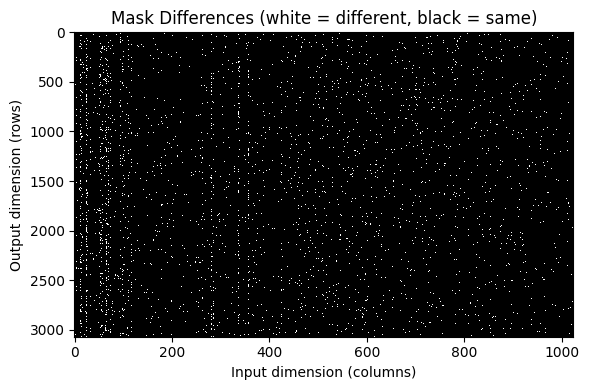

Text(0, 0.5, 'Output dimension (rows)')

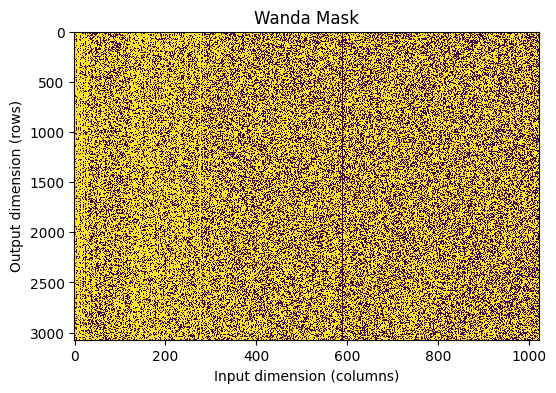

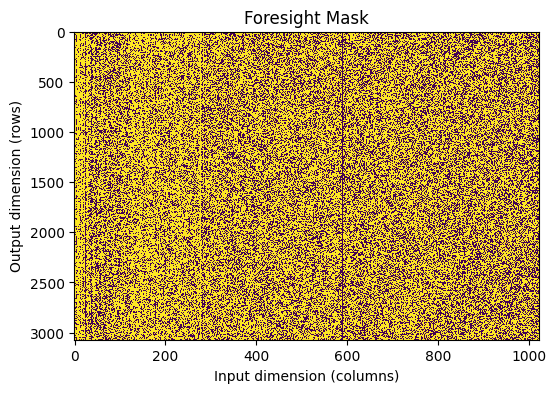

In [9]:
wanda_mask_bool = torch.load("assets/wanda_mask_bool.pt", map_location="cpu")  # or "cuda"
foresight_mask_bool = torch.load("assets/foresight_mask_bool.pt", map_location="cpu")  # or "cuda"
acc = (wanda_mask_bool == foresight_mask_bool).float().mean().item()
print(f"Mask agreement between Wanda and Foresight: {acc:.2%}")

difference_bool = (wanda_mask_bool != foresight_mask_bool)
plt.figure(figsize=(6, 4))
plt.imshow(difference_bool.numpy(), aspect="auto", interpolation="nearest", cmap="gray")
plt.title("Mask Differences (white = different, black = same)")
plt.xlabel("Input dimension (columns)")
plt.ylabel("Output dimension (rows)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(wanda_mask_bool.numpy(), aspect="auto", interpolation="nearest")
plt.title("Wanda Mask")
plt.xlabel("Input dimension (columns)")
plt.ylabel("Output dimension (rows)")

plt.figure(figsize=(6, 4))
plt.imshow(foresight_mask_bool.numpy(), aspect="auto", interpolation="nearest")
plt.title("Foresight Mask")
plt.xlabel("Input dimension (columns)")
plt.ylabel("Output dimension (rows)")

In [5]:
from pruning.utils import check_sparsity
model = peft_model.merge_and_unload()
sparsity = check_sparsity(model)
print(f"Sparsity after pruning: {sparsity:.2%}")

layer 0 sparsity 0.399544
layer 1 sparsity 0.399544
layer 2 sparsity 0.399544
layer 3 sparsity 0.399545
layer 4 sparsity 0.399545
layer 5 sparsity 0.399544
layer 6 sparsity 0.399544
layer 7 sparsity 0.399545
layer 8 sparsity 0.399545
layer 9 sparsity 0.399545
layer 10 sparsity 0.399544
layer 11 sparsity 0.399545
layer 12 sparsity 0.399544
layer 13 sparsity 0.399544
layer 14 sparsity 0.399545
layer 15 sparsity 0.399544
layer 16 sparsity 0.399544
layer 17 sparsity 0.399545
layer 18 sparsity 0.399544
layer 19 sparsity 0.399545
layer 20 sparsity 0.399545
layer 21 sparsity 0.399545
layer 22 sparsity 0.399544
layer 23 sparsity 0.399544
layer 24 sparsity 0.399544
layer 25 sparsity 0.399544
layer 26 sparsity 0.399545
layer 27 sparsity 0.399545
Sparsity after pruning: 39.95%


In [6]:
from evaluation.perplexity import eval_ppl
ppl = eval_ppl(model = model, tokenizer=tokenizer, dataset="harrison", seqlen=2048)
print (f"Perplexity after pruning: {ppl}")

evaluating on harrison


block 0/300
block 50/300
block 100/300
block 150/300
block 200/300
block 250/300
Perplexity after pruning: 22.045287138581553


In [7]:
from evaluation.domain_zero_shot import evaluate_pubmedqa, evaluate_mednli, evaluate_hqs

post = {}
acc, maf, cm, predictions = evaluate_pubmedqa(model, tokenizer)
print(f"PubMedQA Accuracy after fine-tuning: {acc:.4f}, Macro F1: {maf:.4f}")
post["PubMedQA"] = {"accuracy": float(acc), "macro_f1": float(maf)}
acc, maf, cm, predictions = evaluate_mednli(model, tokenizer)
print(f"MedNLI Accuracy after fine-tuning: {acc:.4f}, Macro F1: {maf:.4f}")
post["MedNLI"] = {"accuracy": float(acc), "macro_f1": float(maf)}
rouge, prediction = evaluate_hqs(model, tokenizer)
print("HQS ROUGE after fine-tuning:", rouge)
post["HQS"] = {"rouge": rouge}

Predicting final decisions: 100%|██████████| 500/500 [01:41<00:00,  4.94it/s]


=== PubMedQA Results ===
Saved detailed log to: /home/918839576/Trepo/Efficient_Domain_Adaptation/assets/pubmedqa_predictions.txt
Accuracy = 0.6460
Macro-F1 = 0.4419
Macro-F1 95% bootstrap CI (n_boot=1000): [0.4111, 0.4702]
PubMedQA Accuracy after fine-tuning: 0.6460, Macro F1: 0.4419


Evaluating MedNLI: 100%|██████████| 1422/1422 [04:39<00:00,  5.09it/s]


=== MedNLI Results ===
Saved detailed log to: /home/918839576/Trepo/Efficient_Domain_Adaptation/assets/mednli_predictions.txt
Accuracy = 0.5373
Macro-F1 = 0.5206
Macro-F1 95% bootstrap CI (n_boot=1000): [0.4939, 0.5468]
MedNLI Accuracy after fine-tuning: 0.5373, Macro F1: 0.5206


Generating Summaries: 100%|██████████| 100/100 [01:35<00:00,  1.04it/s]


=== Final ROUGE SCORES ===
ROUGE-1: 0.3082
ROUGE-2: 0.1121
ROUGE-L: 0.2791

Total generation and evaluation time: 95.79 seconds
HQS ROUGE after fine-tuning: {'rouge1': np.float64(0.3081671339160641), 'rouge2': np.float64(0.11212163928041662), 'rougeL': np.float64(0.27905787464957665), 'rougeLsum': np.float64(0.2796551069441974)}
